# Bayesian Tuning of Phase 5 only with LOOCV, LightGBM vs HistGB

This notebook tries to tune only the fifth stage of the model, the most difficult one, that is to differentiate **Label 1** and **Label 2**, as we can see in the **main.ipynb**, through the use of Leave One Out Cross Validation, given that the sum of the number of observations of the before mentioned labels was 240.
This tuning phase was the most difficult and unique, because training only phase 5 with LOOCV resulted in the use of LightGBM rather than HistGB, visible in **phase5_tuning\checkpoint.json**, the opposite of what was reported when tuning all five phases sequentially.
However, this strategy then led to a deterioration in the submission files, likely due to the limited trials Optuna performed to optimize the hyperparameters, or due to overfitting.

At the end of the tuning there was an ensemble test of the top 5 models, to see if it increased the F1Macro.

## 0. IMPORTS

From section 0 to 3, they are exactly the same things that were written in the other 2 notebooks

In [1]:
import os, random, warnings, json, time
from datetime import timedelta
from collections import Counter
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from scipy.sparse import hstack, csr_matrix

from lightgbm import LGBMClassifier

import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 359956
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

c:\Users\simop\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. DATA & PREPROCESSING

In [2]:

for res in ["punkt", "punkt_tab", "wordnet", "stopwords",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(res, quiet=True)

df = pd.read_csv("train.csv").dropna(subset=["TEXT", "LABEL"]).reset_index(drop=True)
print(f"Loaded {len(df)} rows")

lemmatizer = WordNetLemmatizer()

def clean_text_none(text):
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("Cleaning texts")
df["text_clean"] = df["TEXT"].apply(clean_text_none)

print("Extracting stylometric features")

def extract_stylometric(text):
    text = str(text)
    sentences = sent_tokenize(text)
    n_sentences = max(len(sentences), 1)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    words = word_tokenize(text)
    alpha_words = [w for w in words if w.isalpha()]
    n_words = max(len(alpha_words), 1)
    word_lengths = [len(w) for w in alpha_words] if alpha_words else [0]
    n_chars = max(len(text), 1)
    n_commas = text.count(",")
    n_periods = text.count(".")
    n_exclaim = text.count("!")
    n_question = text.count("?")
    n_semicolon = text.count(";")
    n_colon = text.count(":")
    n_dash = text.count("\u2014") + text.count("-")
    n_parens = text.count("(") + text.count(")")
    n_quotes = text.count('"') + text.count("'") + text.count("\u201c") + text.count("\u201d")
    try:
        tags = pos_tag(alpha_words[:200])
        tag_counts = Counter(t for _, t in tags)
        n_tagged = max(sum(tag_counts.values()), 1)
        pct_noun = (tag_counts.get("NN", 0) + tag_counts.get("NNS", 0) + tag_counts.get("NNP", 0) + tag_counts.get("NNPS", 0)) / n_tagged
        pct_verb = (tag_counts.get("VB", 0) + tag_counts.get("VBD", 0) + tag_counts.get("VBG", 0) + tag_counts.get("VBN", 0) + tag_counts.get("VBP", 0) + tag_counts.get("VBZ", 0)) / n_tagged
        pct_adj = (tag_counts.get("JJ", 0) + tag_counts.get("JJR", 0) + tag_counts.get("JJS", 0)) / n_tagged
        pct_adv = (tag_counts.get("RB", 0) + tag_counts.get("RBR", 0) + tag_counts.get("RBS", 0)) / n_tagged
    except:
        pct_noun = pct_verb = pct_adj = pct_adv = 0.0
    unique_words = set(w.lower() for w in alpha_words)
    ttr = len(unique_words) / n_words
    pct_short = sum(1 for w in alpha_words if len(w) <= 3) / n_words
    pct_long = sum(1 for w in alpha_words if len(w) >= 8) / n_words
    return {"n_chars": n_chars, "n_words": n_words, "n_sentences": n_sentences,
        "avg_word_len": np.mean(word_lengths), "std_word_len": np.std(word_lengths),
        "avg_sent_len": np.mean(sent_lengths),
        "std_sent_len": np.std(sent_lengths) if len(sent_lengths) > 1 else 0,
        "max_sent_len": max(sent_lengths), "min_sent_len": min(sent_lengths),
        "comma_rate": n_commas / n_words, "period_rate": n_periods / n_words,
        "exclaim_rate": n_exclaim / n_words, "question_rate": n_question / n_words,
        "semicolon_rate": n_semicolon / n_words, "colon_rate": n_colon / n_words,
        "dash_rate": n_dash / n_words, "paren_rate": n_parens / n_words,
        "quote_rate": n_quotes / n_words,
        "total_punct_rate": (n_commas + n_periods + n_exclaim + n_question + n_semicolon + n_colon) / n_words,
        "pct_noun": pct_noun, "pct_verb": pct_verb, "pct_adj": pct_adj, "pct_adv": pct_adv,
        "noun_verb_ratio": pct_noun / max(pct_verb, 0.001),
        "ttr": ttr, "pct_short_words": pct_short, "pct_long_words": pct_long,
        "words_per_sentence": n_words / n_sentences, "chars_per_word": n_chars / n_words}

stylo_df = pd.DataFrame(df["TEXT"].apply(extract_stylometric).tolist())
STYLO_ALL = stylo_df.values.astype(float)

STYLO_GROUPS = {
    "all_30": list(range(29)), "punctuation": list(range(9, 19)),
    "pos": list(range(19, 24)), "length": list(range(0, 9)),
    "vocabulary": list(range(24, 27)), "structure": [27, 28],
    "punct_pos": list(range(9, 24)),
    "punct_pos_vocab": list(range(9, 24)) + list(range(24, 27)),
    "no_length": list(range(9, 29)),
    "no_pos": list(range(0, 19)) + list(range(24, 29)),
}

print(f"Stylometric features: {STYLO_ALL.shape}")
print("Done.\n")



Loaded 2400 rows
Cleaning texts
Extracting stylometric features
Stylometric features: (2400, 29)
Done.



## 2. GLOBALS Label 1+2 subset

In [3]:
MASK_12 = np.isin(df["LABEL"].values, [1, 2])
IDX_12 = np.where(MASK_12)[0]
TEXTS_12 = df["text_clean"].values[IDX_12]
LABELS_12 = df["LABEL"].values[IDX_12]
STYLO_12 = STYLO_ALL[IDX_12]
N_SAMPLES = len(IDX_12)

print(f"Label 1+2: {N_SAMPLES} samples (Label 1: {(LABELS_12==1).sum()}, Label 2: {(LABELS_12==2).sum()})")
print(f"Using LOOCV: {N_SAMPLES} iterations per trial\n")

N_TRIALS = 1200

TUNING_DIR = Path("phase5_tuning")
TUNING_DIR.mkdir(exist_ok=True)
CHECKPOINT_FILE = TUNING_DIR / "checkpoint.json"
RESULTS_FILE = TUNING_DIR / "results.json"
TOP5_FILE = TUNING_DIR / "top5.json"
ENSEMBLE_FILE = TUNING_DIR / "ensemble_results.json"
DB_FILE = TUNING_DIR / "optuna_study.db"

Label 1+2: 240 samples (Label 1: 80, Label 2: 160)
Using LOOCV: 240 iterations per trial



In [4]:
def build_impchi(X_tr_text, X_val_text, y_tr, k_per_class,
                 max_feat=15000, ngram_min=1, ngram_max=2, min_df=2, sublinear=True):
    tfidf = TfidfVectorizer(max_features=max_feat, ngram_range=(ngram_min, ngram_max),
                            sublinear_tf=sublinear, min_df=min_df,
                            strip_accents="unicode", analyzer="word")
    X_tr_full = tfidf.fit_transform(X_tr_text)
    X_val_full = tfidf.transform(X_val_text)
    classes = np.unique(y_tr)
    selected = set()
    for cls in classes:
        y_bin = (y_tr == cls).astype(int)
        scores, _ = chi2(X_tr_full, y_bin)
        top_k = np.argsort(scores)[-k_per_class:]
        selected.update(top_k)
    sel = sorted(selected)
    return X_tr_full[:, sel], X_val_full[:, sel]


def build_stylo(tr_idx, val_idx, col_indices):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(STYLO_12[tr_idx][:, col_indices])
    X_val = scaler.transform(STYLO_12[val_idx][:, col_indices])
    return csr_matrix(X_tr), csr_matrix(X_val)


## 4. OPTUNA OBJECTIVE

In [5]:
def objective(trial):
    # ── ImpCHI params ─────────────────────────────────────────
    impchi_k = trial.suggest_int("impchi_k", 10, 100)
    impchi_max_feat = trial.suggest_int("impchi_max_feat", 5000, 20000, log=True)
    impchi_ngram_min = trial.suggest_int("impchi_ngram_min", 1, 2)
    impchi_ngram_max = trial.suggest_int("impchi_ngram_max", 1, 3)
    # Ensure min <= max
    if impchi_ngram_min > impchi_ngram_max:
        impchi_ngram_min, impchi_ngram_max = impchi_ngram_max, impchi_ngram_min
    impchi_min_df = trial.suggest_int("impchi_min_df", 1, 5)
    impchi_sublinear = trial.suggest_categorical("impchi_sublinear", [True, False])

    # ── Stylometric params ────────────────────────────────────
    stylo_subset = trial.suggest_categorical("stylo_subset",
        ["all_30", "punctuation", "pos", "length", "vocabulary",
         "punct_pos", "punct_pos_vocab", "no_length", "no_pos"])
    stylo_cols = STYLO_GROUPS[stylo_subset]

    # ── Model choice ──────────────────────────────────────────
    model_type = trial.suggest_categorical("model_type", ["histgb", "lightgbm"])

    # ── Model params (shared names where possible) ────────────
    max_iter = trial.suggest_int("max_iter", 30, 300)
    max_depth = trial.suggest_int("max_depth", 2, 16)
    lr = trial.suggest_float("lr", 0.005, 0.3, log=True)
    max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 3, 31)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 30)
    l2_reg = trial.suggest_float("l2_reg", 0.0, 10.0)
    cw = trial.suggest_categorical("class_weight", ["balanced", "none"])

    # LightGBM-specific
    if model_type == "lightgbm":
        lgb_subsample = trial.suggest_float("lgb_subsample", 0.5, 1.0)
        lgb_colsample = trial.suggest_float("lgb_colsample", 0.5, 1.0)

    # ── LOOCV ─────────────────────────────────────────────────
    loo_preds = np.zeros(N_SAMPLES, dtype=int)

    for i in range(N_SAMPLES):
        tr_mask = np.ones(N_SAMPLES, dtype=bool)
        tr_mask[i] = False
        tr_idx = np.where(tr_mask)[0]
        val_idx = np.array([i])
        y_tr = LABELS_12[tr_idx]

        # ImpCHI
        X_tr_chi, X_val_chi = build_impchi(
            TEXTS_12[tr_idx], TEXTS_12[val_idx], y_tr,
            k_per_class=impchi_k, max_feat=impchi_max_feat,
            ngram_min=impchi_ngram_min, ngram_max=impchi_ngram_max,
            min_df=impchi_min_df, sublinear=impchi_sublinear)

        # Stylo
        X_tr_sty, X_val_sty = build_stylo(tr_idx, val_idx, stylo_cols)

        # Concat
        X_tr = hstack([X_tr_chi, X_tr_sty]).toarray()
        X_val = hstack([X_val_chi, X_val_sty]).toarray()

        # Model
        if model_type == "histgb":
            m = HistGradientBoostingClassifier(
                max_iter=max_iter, max_depth=max_depth,
                learning_rate=lr, max_leaf_nodes=max_leaf_nodes,
                min_samples_leaf=min_samples_leaf,
                l2_regularization=l2_reg,
                class_weight="balanced" if cw == "balanced" else None,
                random_state=SEED)
            m.fit(X_tr, y_tr)
            loo_preds[i] = m.predict(X_val)[0]
        else:  # lightgbm
            le = LabelEncoder()
            y_tr_enc = le.fit_transform(y_tr)
            m = LGBMClassifier(
                n_estimators=max_iter, max_depth=max_depth,
                learning_rate=lr, num_leaves=max_leaf_nodes,
                min_child_samples=min_samples_leaf,
                reg_lambda=l2_reg,
                subsample=lgb_subsample, colsample_bytree=lgb_colsample,
                subsample_freq=1,
                class_weight="balanced" if cw == "balanced" else None,
                random_state=SEED, verbosity=-1, n_jobs=1)
            m.fit(X_tr, y_tr_enc)
            loo_preds[i] = le.inverse_transform(m.predict(X_val))[0]

    return float(f1_score(LABELS_12, loo_preds, average="macro"))


## 5. Helper function to save CHECKPOINT

In [6]:
def save_checkpoint(study):
    records = []
    for t in study.trials:
        if t.state == optuna.trial.TrialState.COMPLETE:
            records.append({
                "number": t.number,
                "f1_loocv": t.value,
                "params": t.params,
                "duration_s": round(t.duration.total_seconds(), 1) if t.duration else None,
            })
    records.sort(key=lambda x: x["f1_loocv"], reverse=True)
    with open(CHECKPOINT_FILE, "w") as fp:
        json.dump(records, fp, indent=2, default=str)
    return len(records)

def load_completed_count():
    if CHECKPOINT_FILE.exists():
        with open(CHECKPOINT_FILE, "r") as fp:
            return len(json.load(fp))
    return 0


## 6. RUN OPTUNA

In [7]:
already_done = load_completed_count()
remaining = max(0, N_TRIALS - already_done)

print(f"Target: (N_TRIALS={N_TRIALS})")
print(f"Already completed: {already_done}")
print(f"Remaining: {remaining}")

if remaining == 0:
    print("Max trials reached. Increase N_TRIALS or skip to results.")
else:
    storage_path = f"sqlite:///{DB_FILE}"
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=SEED),
        study_name="phase5_loocv_v2",
        storage=storage_path,
        load_if_exists=True,
    )

    t0 = time.time()
    best_so_far = [0.0]
    completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    if completed:
        best_so_far[0] = max(t.value for t in completed)

    def trial_callback(study, trial):
        elapsed = time.time() - t0
        n_new = trial.number + 1 - already_done
        if n_new <= 0:
            return
        avg = elapsed / n_new
        rem_time = avg * 100  # just show estimate for next 100

        if trial.value and trial.value > best_so_far[0]:
            best_so_far[0] = trial.value

        if n_new % 10 == 0 or n_new == 1:
            print(
                f"  Trial {trial.number+1:>6d} (new #{n_new})  "
                f"F1_LOOCV={trial.value:.4f}  "
                f"best={best_so_far[0]:.4f}  "
                f"model={trial.params.get('model_type', '?'):<8s}  "
            )

        if n_new % 10 == 0:
            n_saved = save_checkpoint(study)
            print(f"    [CHECKPOINT] {n_saved} trials -> {CHECKPOINT_FILE}")

    print(f"Starting Optuna\n")
    study.optimize(objective, n_trials=remaining, callbacks=[trial_callback])

    total_time = time.time() - t0
    print(f"\nFinished. {timedelta(seconds=int(total_time))}")
    save_checkpoint(study)
    

Target: (N_TRIALS=1200)
Already completed: 1189
Remaining: 11
Starting Optuna


Finished. 0:05:36



## 7. SAVE RESULTS


In [8]:
if CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)
    with open(RESULTS_FILE, "w") as fp:
        json.dump(all_results, fp, indent=2, default=str)
    print(f"Saved {len(all_results)} trials -> {RESULTS_FILE}")
else:
    all_results = []
    print("No checkpoint found.")



Saved 538 trials -> phase5_tuning\results.json


## 8. TOP 5 FROM OPTUNA

In [9]:
if not all_results and CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)

top5 = all_results[:5]

print(f"\nLoaded {len(all_results)} trials.\n")
print("=" * 90)
print("  TOP 5 (by LOOCV macro F1)")
print("=" * 90)

for rank, r in enumerate(top5, 1):
    p = r["params"]
    print(f"\n  #{rank}  Trial {r['number']}  F1_LOOCV = {r['f1_loocv']:.4f}  ({r.get('duration_s',0):.0f}s)")
    print(f"    Model:  {p['model_type']}")
    print(f"    ImpCHI: k={p['impchi_k']}, feat={p['impchi_max_feat']}, "
          f"ngram=({p['impchi_ngram_min']},{p['impchi_ngram_max']}), "
          f"min_df={p['impchi_min_df']}, sublinear={p['impchi_sublinear']}")
    print(f"    Stylo:  {p['stylo_subset']}")
    print(f"    Tree:   iters={p['max_iter']}, depth={p['max_depth']}, "
          f"lr={p['lr']:.4f}, leaves={p['max_leaf_nodes']}, "
          f"min_leaf={p['min_samples_leaf']}, l2={p['l2_reg']:.2f}, "
          f"cw={p['class_weight']}")

with open(TOP5_FILE, "w") as fp:
    json.dump(top5[:5], fp, indent=2, default=str)
print(f"\nSaved top 5 > {TOP5_FILE}")




Loaded 538 trials.

  TOP 5 (by LOOCV macro F1)

  #1  Trial 303  F1_LOOCV = 0.8839  (24s)
    Model:  lightgbm
    ImpCHI: k=78, feat=12156, ngram=(1,2), min_df=3, sublinear=True
    Stylo:  all_30
    Tree:   iters=189, depth=3, lr=0.0451, leaves=24, min_leaf=19, l2=0.36, cw=balanced

  #2  Trial 368  F1_LOOCV = 0.8839  (16s)
    Model:  lightgbm
    ImpCHI: k=69, feat=11562, ngram=(1,2), min_df=3, sublinear=True
    Stylo:  all_30
    Tree:   iters=184, depth=3, lr=0.0369, leaves=23, min_leaf=19, l2=0.61, cw=balanced

  #3  Trial 375  F1_LOOCV = 0.8839  (16s)
    Model:  lightgbm
    ImpCHI: k=73, feat=11967, ngram=(1,2), min_df=3, sublinear=True
    Stylo:  all_30
    Tree:   iters=189, depth=3, lr=0.0408, leaves=23, min_leaf=19, l2=0.79, cw=balanced

  #4  Trial 271  F1_LOOCV = 0.8832  (24s)
    Model:  lightgbm
    ImpCHI: k=51, feat=12441, ngram=(1,2), min_df=1, sublinear=True
    Stylo:  all_30
    Tree:   iters=176, depth=3, lr=0.0446, leaves=26, min_leaf=14, l2=0.79, cw=bala

## 9. PROBABILITY ENSEMBLE - Top 5 models

For each top model, run LOOCV saving predict_proba.
Then test all C(5,3) = 10 combinations of 3 models: average probabilities --> argmax --> F1

In [10]:
# Store per-model probabilities: shape (n_models, N_SAMPLES, 2)
model_probas = []
model_infos = []

for rank, r in enumerate(top5, 1):
    p = r["params"]
    stylo_cols = STYLO_GROUPS[p["stylo_subset"]]
    model_type = p["model_type"]

    print(f"\n  Model #{rank} (Trial {r['number']}, F1={r['f1_loocv']:.4f}) - {model_type}")

    probas = np.zeros((N_SAMPLES, 2))  # columns: P(class1), P(class2)
    t_start = time.time()

    for i in range(N_SAMPLES):
        tr_mask = np.ones(N_SAMPLES, dtype=bool)
        tr_mask[i] = False
        tr_idx = np.where(tr_mask)[0]
        val_idx = np.array([i])
        y_tr = LABELS_12[tr_idx]

        X_tr_chi, X_val_chi = build_impchi(
            TEXTS_12[tr_idx], TEXTS_12[val_idx], y_tr,
            k_per_class=p["impchi_k"], max_feat=p["impchi_max_feat"],
            ngram_min=p["impchi_ngram_min"], ngram_max=p["impchi_ngram_max"],
            min_df=p["impchi_min_df"], sublinear=p["impchi_sublinear"])

        X_tr_sty, X_val_sty = build_stylo(tr_idx, val_idx, stylo_cols)
        X_tr = hstack([X_tr_chi, X_tr_sty]).toarray()
        X_val = hstack([X_val_chi, X_val_sty]).toarray()

        if model_type == "histgb":
            m = HistGradientBoostingClassifier(
                max_iter=p["max_iter"], max_depth=p["max_depth"],
                learning_rate=p["lr"], max_leaf_nodes=p["max_leaf_nodes"],
                min_samples_leaf=p["min_samples_leaf"],
                l2_regularization=p["l2_reg"],
                class_weight="balanced" if p["class_weight"] == "balanced" else None,
                random_state=SEED)
            m.fit(X_tr, y_tr)
            proba = m.predict_proba(X_val)[0]
            # Map to consistent [P(label1), P(label2)]
            classes = m.classes_
        else:
            le = LabelEncoder()
            y_tr_enc = le.fit_transform(y_tr)
            m = LGBMClassifier(
                n_estimators=p["max_iter"], max_depth=p["max_depth"],
                learning_rate=p["lr"], num_leaves=p["max_leaf_nodes"],
                min_child_samples=p["min_samples_leaf"],
                reg_lambda=p["l2_reg"],
                subsample=p.get("lgb_subsample", 0.8),
                colsample_bytree=p.get("lgb_colsample", 0.8),
                subsample_freq=1,
                class_weight="balanced" if p["class_weight"] == "balanced" else None,
                random_state=SEED, verbosity=-1, n_jobs=1)
            m.fit(X_tr, y_tr_enc)
            proba = m.predict_proba(X_val)[0]
            classes = le.classes_  # encoded: 0, 1

        # Normalize to [P(original_label_1), P(original_label_2)]
        # classes could be [1, 2] (histgb) or [0, 1] (lightgbm encoded)
        probas[i, 0] = proba[0]  # P(first class)
        probas[i, 1] = proba[1]  # P(second class)

    elapsed = time.time() - t_start

    # Verify single-model F1 from probas
    pred_from_proba = np.where(probas[:, 0] > probas[:, 1], 1, 2)
    f1_check = f1_score(LABELS_12, pred_from_proba, average="macro")
    print(f"    F1 from proba: {f1_check:.4f}  ({elapsed:.0f}s)")

    model_probas.append(probas)
    model_infos.append({
        "rank": rank, "trial": r["number"],
        "f1_loocv": r["f1_loocv"], "f1_from_proba": f1_check,
        "model_type": model_type, "params": p
    })




  Model #1 (Trial 303, F1=0.8839) - lightgbm
    F1 from proba: 0.8839  (28s)

  Model #2 (Trial 368, F1=0.8839) - lightgbm
    F1 from proba: 0.8839  (25s)

  Model #3 (Trial 375, F1=0.8839) - lightgbm
    F1 from proba: 0.8839  (24s)

  Model #4 (Trial 271, F1=0.8832) - lightgbm
    F1 from proba: 0.8832  (25s)

  Model #5 (Trial 285, F1=0.8832) - lightgbm
    F1 from proba: 0.8832  (27s)


# 10. ENSEMBLE SEARCH, all 10 comb.

In [11]:
n_models = len(model_probas)
ensemble_results = []

# Test all combinations of 3 models
for combo in combinations(range(n_models), 3):
    avg_proba = np.mean([model_probas[j] for j in combo], axis=0)
    preds = np.where(avg_proba[:, 0] > avg_proba[:, 1], 1, 2)
    f1 = f1_score(LABELS_12, preds, average="macro")

    ensemble_results.append({
        "models": list(combo),
        "model_trials": [model_infos[j]["trial"] for j in combo],
        "model_types": [model_infos[j]["model_type"] for j in combo],
        "f1_ensemble": f1,
        "individual_f1s": [model_infos[j]["f1_loocv"] for j in combo],
    })

# Also test pairs (C(n,2)) and quads (C(n,4))
for k in [2, 4, 5]:
    if n_models >= k:
        for combo in combinations(range(n_models), k):
            avg_proba = np.mean([model_probas[j] for j in combo], axis=0)
            preds = np.where(avg_proba[:, 0] > avg_proba[:, 1], 1, 2)
            f1 = f1_score(LABELS_12, preds, average="macro")
            ensemble_results.append({
                "models": list(combo),
                "model_trials": [model_infos[j]["trial"] for j in combo],
                "model_types": [model_infos[j]["model_type"] for j in combo],
                "f1_ensemble": f1,
                "individual_f1s": [model_infos[j]["f1_loocv"] for j in combo],
            })

ensemble_results.sort(key=lambda x: x["f1_ensemble"], reverse=True)

print(f"\nTested {len(ensemble_results)} ensemble combinations.\n")
print(f"{'Rank':<5} {'Size':<5} {'F1_ensemble':>12} {'Models':>30} {'Types'}")
print("-" * 80)

for rank, e in enumerate(ensemble_results[:15], 1):
    models_str = str(e["model_trials"])
    types_str = str(e["model_types"])
    print(f"{rank:<5} {len(e['models']):<5} {e['f1_ensemble']:>12.4f} {models_str:>30} {types_str}")

# Best single vs best ensemble
best_single = max(model_infos, key=lambda x: x["f1_loocv"])
best_ensemble = ensemble_results[0]

print(f"\n  Best single model: Trial {best_single['trial']}, F1={best_single['f1_loocv']:.4f}")
print(f"  Best ensemble:     {best_ensemble['model_trials']}, F1={best_ensemble['f1_ensemble']:.4f}")
print(f"  Improvement:       {best_ensemble['f1_ensemble'] - best_single['f1_loocv']:+.4f}")

with open(ENSEMBLE_FILE, "w") as fp:
    json.dump({
        "individual_models": model_infos,
        "best_ensembles": ensemble_results[:20],
        "best_single_f1": best_single["f1_loocv"],
        "best_ensemble_f1": best_ensemble["f1_ensemble"],
    }, fp, indent=2, default=str)
print(f"\nSaved: {ENSEMBLE_FILE}")



Tested 26 ensemble combinations.

Rank  Size   F1_ensemble                         Models Types
--------------------------------------------------------------------------------
1     3           0.8882                [303, 368, 285] ['lightgbm', 'lightgbm', 'lightgbm']
2     3           0.8882                [368, 271, 285] ['lightgbm', 'lightgbm', 'lightgbm']
3     3           0.8882                [375, 271, 285] ['lightgbm', 'lightgbm', 'lightgbm']
4     4           0.8882           [303, 368, 271, 285] ['lightgbm', 'lightgbm', 'lightgbm', 'lightgbm']
5     4           0.8882           [303, 375, 271, 285] ['lightgbm', 'lightgbm', 'lightgbm', 'lightgbm']
6     5           0.8882      [303, 368, 375, 271, 285] ['lightgbm', 'lightgbm', 'lightgbm', 'lightgbm', 'lightgbm']
7     2           0.8875                     [271, 285] ['lightgbm', 'lightgbm']
8     3           0.8839                [303, 368, 375] ['lightgbm', 'lightgbm', 'lightgbm']
9     3           0.8839                [3

## 11. PLOTS

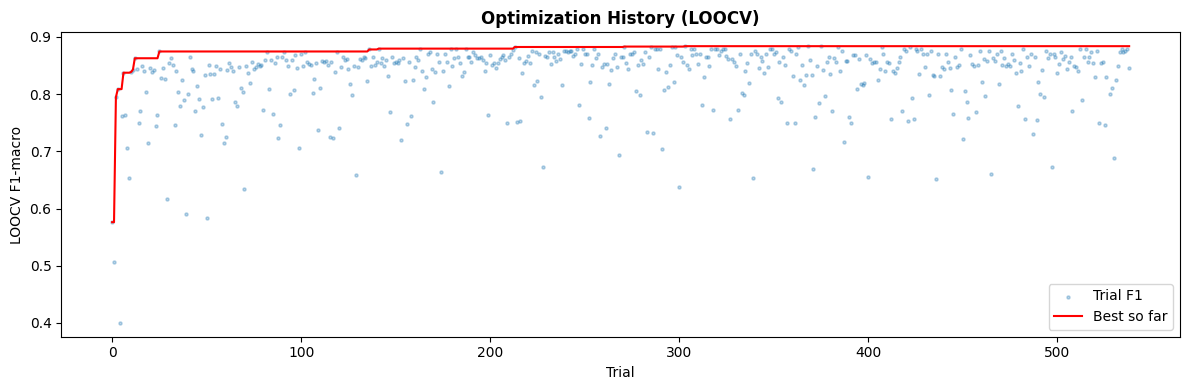

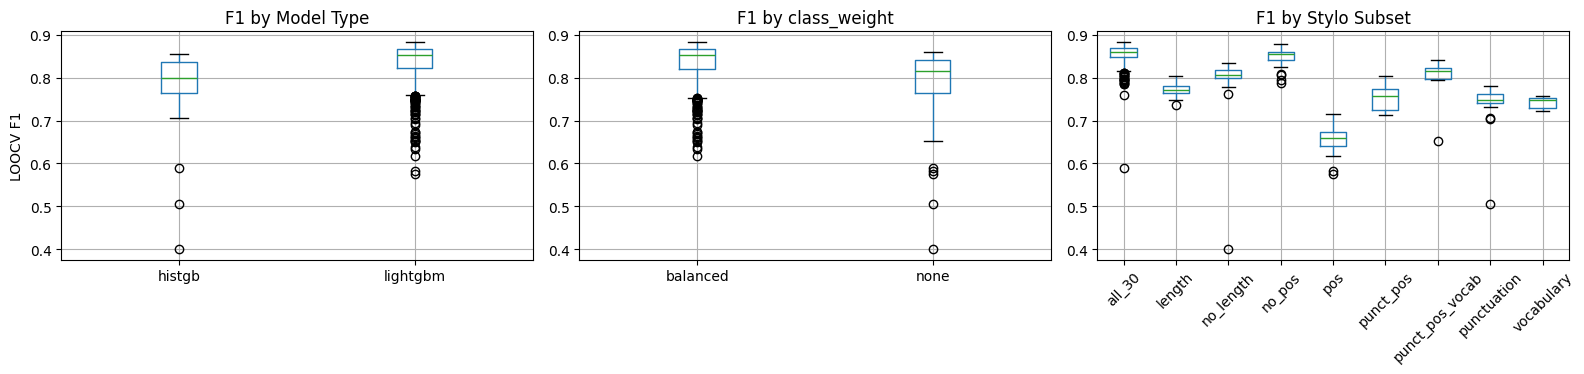

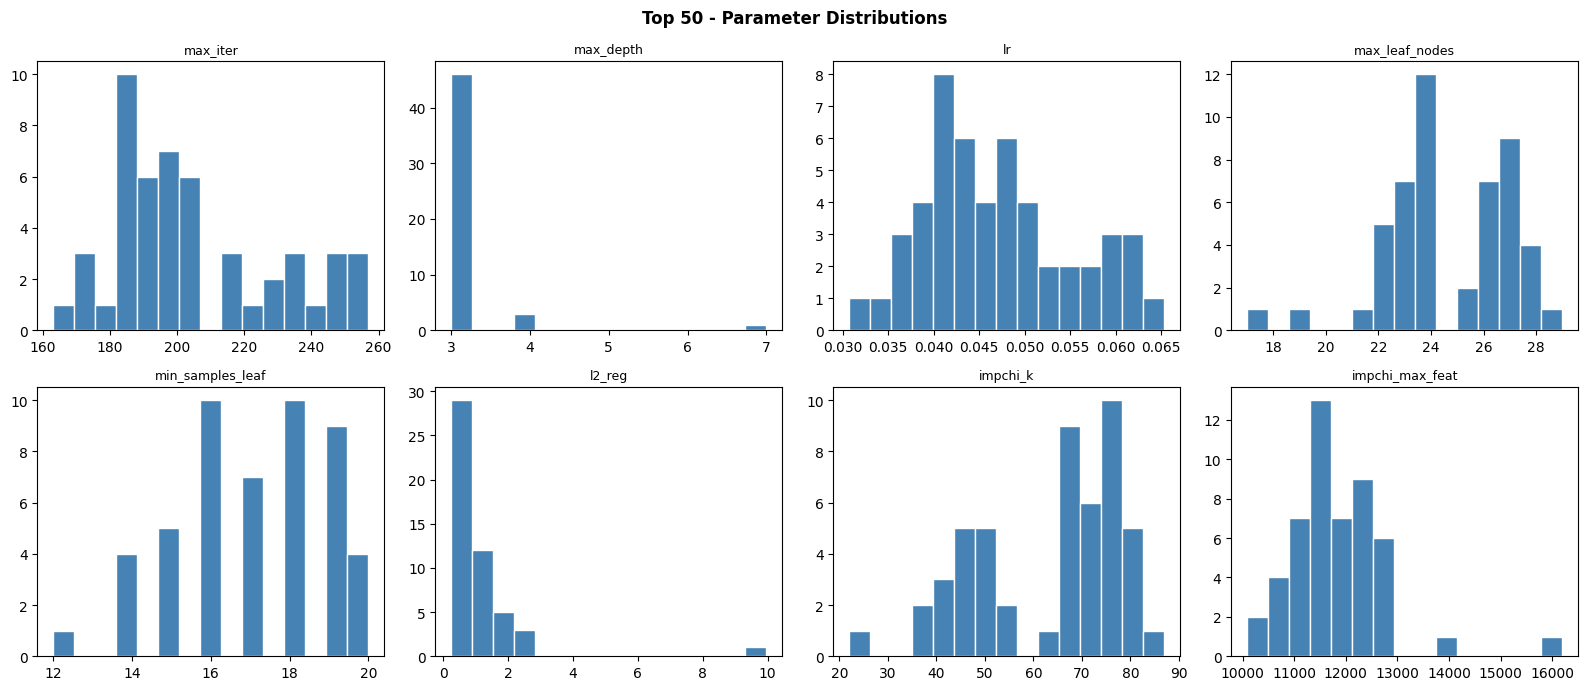

In [12]:
if not all_results and CHECKPOINT_FILE.exists():
    with open(CHECKPOINT_FILE, "r") as fp:
        all_results = json.load(fp)

if all_results:
    # ── Optimization history ──────────────────────────────────
    trial_nums = [r["number"] for r in all_results]
    f1_vals = [r["f1_loocv"] for r in all_results]
    order = np.argsort(trial_nums)
    t_sorted = np.array(trial_nums)[order]
    f1_sorted = np.array(f1_vals)[order]
    cummax = np.maximum.accumulate(f1_sorted)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.scatter(t_sorted, f1_sorted, s=5, alpha=0.3, label="Trial F1")
    ax.plot(t_sorted, cummax, color="red", linewidth=1.5, label="Best so far")
    ax.set_xlabel("Trial")
    ax.set_ylabel("LOOCV F1-macro")
    ax.set_title("Optimization History (LOOCV)", fontweight="bold")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # ── Model type comparison ─────────────────────────────────
    df_r = pd.DataFrame(all_results)
    df_r["model"] = df_r["params"].apply(lambda p: p.get("model_type", "?"))
    df_r["stylo"] = df_r["params"].apply(lambda p: p.get("stylo_subset", "?"))
    df_r["cw"] = df_r["params"].apply(lambda p: p.get("class_weight", "?"))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    df_r.boxplot(column="f1_loocv", by="model", ax=axes[0])
    axes[0].set_title("F1 by Model Type")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("LOOCV F1")

    df_r.boxplot(column="f1_loocv", by="cw", ax=axes[1])
    axes[1].set_title("F1 by class_weight")
    axes[1].set_xlabel("")

    df_r.boxplot(column="f1_loocv", by="stylo", ax=axes[2], rot=45)
    axes[2].set_title("F1 by Stylo Subset")
    axes[2].set_xlabel("")

    plt.suptitle("")
    plt.tight_layout()
    plt.show()

    # ── Top 50 param distributions ────────────────────────────
    top50 = all_results[:50]
    keys = ["max_iter", "max_depth", "lr", "max_leaf_nodes",
            "min_samples_leaf", "l2_reg", "impchi_k", "impchi_max_feat"]
    fig, axes = plt.subplots(2, 4, figsize=(16, 7))
    axes = axes.flatten()
    for idx, key in enumerate(keys):
        vals = [r["params"].get(key) for r in top50 if r["params"].get(key) is not None]
        if vals:
            axes[idx].hist(vals, bins=15, color="steelblue", edgecolor="white")
            axes[idx].set_title(key, fontsize=9)
    fig.suptitle("Top 50 - Parameter Distributions", fontweight="bold")
    plt.tight_layout()
    plt.show()

else:
    print("No results to plot.")



## 12. AGGREGATED ANALYSIS

In [13]:
if all_results:
    df_a = pd.DataFrame([{
        "f1": r["f1_loocv"],
        "model": r["params"].get("model_type", "?"),
        "stylo": r["params"].get("stylo_subset", "?"),
        "cw": r["params"].get("class_weight", "?"),
        "sublinear": r["params"].get("impchi_sublinear", "?"),
    } for r in all_results])

    print("\n" + "=" * 60)
    print("  AGGREGATED ANALYSIS")
    print("=" * 60)

    print("\n-- Per model_type --")
    print(df_a.groupby("model")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n-- Per stylo_subset --")
    print(df_a.groupby("stylo")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n-- Per class_weight --")
    print(df_a.groupby("cw")["f1"].agg(["mean", "std", "max", "count"]).round(4)
          .sort_values("max", ascending=False))

    print("\n-- Per impchi_sublinear --")
    print(df_a.groupby("sublinear")["f1"].agg(["mean", "std", "max", "count"]).round(4))

print("\ndone.")



  AGGREGATED ANALYSIS

-- Per model_type --
            mean     std     max  count
model                                  
lightgbm  0.8341  0.0525  0.8839    505
histgb    0.7754  0.1006  0.8560     33

-- Per stylo_subset --
                   mean     std     max  count
stylo                                         
all_30           0.8551  0.0246  0.8839    364
no_pos           0.8490  0.0200  0.8796     51
punct_pos_vocab  0.8058  0.0409  0.8416     18
no_length        0.7840  0.0973  0.8352     18
length           0.7712  0.0166  0.8047     17
punct_pos        0.7546  0.0283  0.8043     17
punctuation      0.7357  0.0608  0.7797     18
vocabulary       0.7423  0.0128  0.7578     17
pos              0.6560  0.0369  0.7150     18

-- Per class_weight --
            mean     std     max  count
cw                                     
balanced  0.8345  0.0503  0.8839    504
none      0.7706  0.1127  0.8609     34

-- Per impchi_sublinear --
             mean     std     max  count
s